# 05 — Geospatial Mobility Analysis

Role: where does taxi demand occur? Pickup and dropoff hotspots, origin-destination
flows, zone-level economics, and how geographic demand shifts across time.

Architecture: every metric in this notebook is aggregable in a single pass over the 12
months — no global threshold depends on a second pass, so every result below is exact,
with no sampling. Zone-keyed accumulators are indexed by LocationID, the zone lookup's
actual key, avoiding any name-collision or merge risk.

Scope: TLC records provide zone codes, not coordinates. This is zone and borough-level
analysis; the map visualizations in Section 12b use the official TLC zone shapefile for
geometry, joined only for display.

Note on year: YEAR = 2025.

In [1]:
import sys
sys.path.append('../src')

import gc
import numpy as np
import pandas as pd
from scipy import stats
import folium

from folium.plugins import HeatMap
from data_loader import load_month, load_zone_lookup, load_zone_shapes
from preprocessing import clean_trips
from feature_engineering import add_features
from visualization import plot_bar, plot_heatmap, save_fig

pd.set_option('display.max_columns', None)
YEAR = 2025
MONTHS = range(1, 13)
OUT_DIR = '../data/outputs'
import os
os.makedirs(OUT_DIR, exist_ok=True)

TOP_N = 15
MIN_OD_VOLUME = 50          # minimum trip count for an OD pair to enter revenue/distance rankings (unstable means otherwise)
MIN_ZONE_TEST_SIZE = 5_000  # minimum zone volume to enter the all-zone weekday/weekend test
MAX_UNMATCHED_RATE_PCT = 5.0  # hard threshold: fail loudly if unmatched LocationIDs exceed this

PAYMENT_TYPE_MAP = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided trip'}

## 1. Zone Lookup — Load and Validate
`LocationID` uniqueness is verified before it is used as a join key anywhere in this
notebook.

In [2]:
zones = load_zone_lookup()
assert zones['LocationID'].is_unique, "zone lookup has duplicate LocationID -- merge/map would be unsafe"

ALL_LOCATION_IDS = sorted(zones['LocationID'].unique().tolist())
zone_display = zones.set_index('LocationID')[['Zone', 'Borough']]
pu_borough_map = zones.set_index('LocationID')['Borough'].to_dict()
do_borough_map = pu_borough_map  # same lookup, applied to DOLocationID

print(f"zone lookup: {len(ALL_LOCATION_IDS)} distinct LocationIDs, uniqueness verified")
zones.head(3)

zone lookup: 265 distinct LocationIDs, uniqueness verified


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone


Results: 265 distinct LocationIDs confirmed unique. The lookup provides Borough,
Zone, and service zone for every code used below.

## 2. Pass 1 — Single Loop Over 12 Months
Every accumulator used in this notebook — zone and borough counts, the OD matrix,
zone-by-month, zone-by-hour, zone-by-weekday, and zone-level economics — is built here
in one pass. A month producing zero rows stops execution immediately.

In [4]:
def new_zone_matrix(cols=None, dtype=np.int64):
    if cols is None:
        return pd.Series(0, index=ALL_LOCATION_IDS, dtype=dtype)
    return pd.DataFrame(0, index=ALL_LOCATION_IDS, columns=cols, dtype=dtype)

monthly_validation = []

pu_zone_counts = new_zone_matrix()
do_zone_counts = new_zone_matrix()
borough_counts_pu = pd.Series(dtype=np.int64)
borough_counts_do = pd.Series(dtype=np.int64)
borough_od_matrix = pd.DataFrame(dtype=np.int64)

od_count = pd.DataFrame(0, index=ALL_LOCATION_IDS, columns=ALL_LOCATION_IDS, dtype=np.int64)
od_fare_sum = pd.DataFrame(0.0, index=ALL_LOCATION_IDS, columns=ALL_LOCATION_IDS)
od_distance_sum = pd.DataFrame(0.0, index=ALL_LOCATION_IDS, columns=ALL_LOCATION_IDS)
od_duration_sum = pd.DataFrame(0.0, index=ALL_LOCATION_IDS, columns=ALL_LOCATION_IDS)

zone_month = new_zone_matrix(cols=list(MONTHS))
zone_hour_pu = new_zone_matrix(cols=list(range(24)))     # pickup zone x pickup hour (correct clock)
zone_hour_do = new_zone_matrix(cols=list(range(24)))     # dropoff zone x DROPOFF hour (fixes prior semantic bug)
zone_weekend = new_zone_matrix(cols=[False, True])        # ALL zones, not just top-10

# per-PU-zone economics: single running-sum table, updated via one groupby/month
zone_econ = pd.DataFrame(0.0, index=ALL_LOCATION_IDS, columns=[
    'trip_count', 'fare_sum', 'distance_sum', 'duration_sum', 'total_sum',
    'toll_trip_count', 'tolls_sum', 'card_trip_count', 'card_tip_sum', 'card_tipped_count',
])

MATCHED_PU = 0
UNMATCHED_PU = 0
MATCHED_DO = 0
UNMATCHED_DO = 0
TOTAL_TRIPS = 0

for m in MONTHS:
    raw = load_month(YEAR, m)
    clean, clean_report = clean_trips(raw)
    del raw

    assert clean_report['output_rows'] > 0, (
        f"month {m}: clean_trips produced ZERO rows (raw={clean_report['input_rows']:,}) -- "
        f"stopping. Do not trust any downstream result until this is investigated."
    )

    featured = add_features(clean)
    del clean

    retention_pct = 100 * clean_report['output_rows'] / clean_report['input_rows']
    monthly_validation.append({
        'month': m, 'raw_rows': clean_report['input_rows'], 'clean_rows': clean_report['output_rows'],
        'retention_pct': round(retention_pct, 2),
    })

    TOTAL_TRIPS += len(featured)

    pu_matched_mask = featured['PULocationID'].isin(ALL_LOCATION_IDS)
    do_matched_mask = featured['DOLocationID'].isin(ALL_LOCATION_IDS)
    MATCHED_PU += int(pu_matched_mask.sum())
    UNMATCHED_PU += int((~pu_matched_mask).sum())
    MATCHED_DO += int(do_matched_mask.sum())
    UNMATCHED_DO += int((~do_matched_mask).sum())

    featured['PU_Borough'] = featured['PULocationID'].map(pu_borough_map)
    featured['DO_Borough'] = featured['DOLocationID'].map(do_borough_map)
    featured['dropoff_hour'] = featured['tpep_dropoff_datetime'].dt.hour
    featured['payment_label'] = featured['payment_type'].map(PAYMENT_TYPE_MAP).fillna('Unknown/Other')

    # zone counts (exact)
    pu_zone_counts = pu_zone_counts.add(featured['PULocationID'].value_counts(), fill_value=0)
    do_zone_counts = do_zone_counts.add(featured['DOLocationID'].value_counts(), fill_value=0)

    # borough counts + borough-to-borough matrix (exact)
    borough_counts_pu = borough_counts_pu.add(featured['PU_Borough'].value_counts(), fill_value=0)
    borough_counts_do = borough_counts_do.add(featured['DO_Borough'].value_counts(), fill_value=0)
    bod = pd.crosstab(featured['PU_Borough'], featured['DO_Borough'])
    borough_od_matrix = borough_od_matrix.add(bod, fill_value=0) if not borough_od_matrix.empty else bod

    # OD matrices: self-pairs excluded BEFORE aggregation
    od_mask = featured['PULocationID'] != featured['DOLocationID']
    od_g = featured.loc[od_mask].groupby(['PULocationID', 'DOLocationID']).agg(
        trip_count=('trip_distance', 'size'), fare_sum=('fare_amount', 'sum'),
        distance_sum=('trip_distance', 'sum'), duration_sum=('trip_duration_min', 'sum'),
    )
    od_count = od_count.add(od_g['trip_count'].unstack(fill_value=0), fill_value=0)
    od_fare_sum = od_fare_sum.add(od_g['fare_sum'].unstack(fill_value=0), fill_value=0)
    od_distance_sum = od_distance_sum.add(od_g['distance_sum'].unstack(fill_value=0), fill_value=0)
    od_duration_sum = od_duration_sum.add(od_g['duration_sum'].unstack(fill_value=0), fill_value=0)

    # zone x month, zone x hour (correct clocks), zone x weekend (ALL zones)
    zone_month[m] = zone_month[m].add(featured['PULocationID'].value_counts(), fill_value=0)
    zone_hour_pu = zone_hour_pu.add(
        pd.crosstab(featured['PULocationID'], featured['pickup_hour']).reindex(
            index=ALL_LOCATION_IDS, columns=range(24), fill_value=0), fill_value=0)
    zone_hour_do = zone_hour_do.add(
        pd.crosstab(featured['DOLocationID'], featured['dropoff_hour']).reindex(
            index=ALL_LOCATION_IDS, columns=range(24), fill_value=0), fill_value=0)
    zone_weekend = zone_weekend.add(
        pd.crosstab(featured['PULocationID'], featured['is_weekend']).reindex(
            index=ALL_LOCATION_IDS, columns=[False, True], fill_value=0), fill_value=0)

    # per-zone economics: one groupby covering all trips, plus a card-only slice for tips
    card_mask = featured['payment_label'] == 'Credit card'
    econ_all = featured.groupby('PULocationID').agg(
        trip_count=('trip_distance', 'size'), fare_sum=('fare_amount', 'sum'),
        distance_sum=('trip_distance', 'sum'), duration_sum=('trip_duration_min', 'sum'),
        total_sum=('total_amount', 'sum'), toll_trip_count=('tolls_amount', lambda s: (s > 0).sum()),
        tolls_sum=('tolls_amount', 'sum'),
    )
    econ_card = featured.loc[card_mask].groupby('PULocationID').agg(
        card_trip_count=('fare_amount', 'size'), card_tip_sum=('tip_amount', 'sum'),
        card_tipped_count=('tip_amount', lambda s: (s > 0).sum()),
    )
    zone_econ[econ_all.columns] = zone_econ[econ_all.columns].add(econ_all, fill_value=0)
    zone_econ[econ_card.columns] = zone_econ[econ_card.columns].add(econ_card, fill_value=0)

    print(f"month={m:02d} raw={clean_report['input_rows']:,} clean={clean_report['output_rows']:,} "
          f"retention={retention_pct:.2f}% aggregated, deleting")
    del featured, od_g, econ_all, econ_card
    gc.collect()

print(f"\nPass 1 complete. TOTAL_TRIPS={TOTAL_TRIPS:,}")

month=01 raw=3,475,226 clean=3,228,827 retention=92.91% aggregated, deleting
month=02 raw=3,577,543 clean=3,285,245 retention=91.83% aggregated, deleting
month=03 raw=4,145,257 clean=3,805,704 retention=91.81% aggregated, deleting
month=04 raw=3,970,553 clean=3,649,927 retention=91.92% aggregated, deleting
month=05 raw=4,591,845 clean=4,069,442 retention=88.62% aggregated, deleting
month=06 raw=4,322,960 clean=3,847,554 retention=89.00% aggregated, deleting
month=07 raw=3,898,963 clean=3,475,039 retention=89.13% aggregated, deleting
month=08 raw=3,574,091 clean=3,164,152 retention=88.53% aggregated, deleting
month=09 raw=4,251,015 clean=3,816,911 retention=89.79% aggregated, deleting
month=10 raw=4,428,699 clean=3,922,487 retention=88.57% aggregated, deleting
month=11 raw=4,181,444 clean=3,624,569 retention=86.68% aggregated, deleting
month=12 raw=4,305,006 clean=4,031,569 retention=93.65% aggregated, deleting

Pass 1 complete. TOTAL_TRIPS=43,921,426


Results: all 12 months processed without incident. 
Cleaning retention ranges from 86.68% (November) to 93.65% (December). 
Total trips after cleaning: 43,921,426.

## 3. Monthly Validation & Match-Rate Checks
Confirms no month collapsed during cleaning and that pickup/dropoff zone codes match
the lookup, before any geographic result depends on either assumption.

In [5]:
monthly_validation_df = pd.DataFrame(monthly_validation)
low_retention = monthly_validation_df[monthly_validation_df['retention_pct'] < 50]
if not low_retention.empty:
    print("WARNING -- months with <50% retention (investigate before trusting downstream results):")
    print(low_retention)
monthly_validation_df

,month,raw_rows,clean_rows,retention_pct
0,1,3475226,3228827,92.91
1,2,3577543,3285245,91.83
2,3,4145257,3805704,91.81
3,4,3970553,3649927,91.92
4,5,4591845,4069442,88.62
5,6,4322960,3847554,89.00
6,7,3898963,3475039,89.13
7,8,3574091,3164152,88.53
8,9,4251015,3816911,89.79
9,10,4428699,3922487,88.57


In [6]:
pu_unmatched_pct = 100 * UNMATCHED_PU / TOTAL_TRIPS
do_unmatched_pct = 100 * UNMATCHED_DO / TOTAL_TRIPS
assert pu_unmatched_pct < MAX_UNMATCHED_RATE_PCT, f"PU unmatched rate {pu_unmatched_pct:.2f}% exceeds {MAX_UNMATCHED_RATE_PCT}% threshold"
assert do_unmatched_pct < MAX_UNMATCHED_RATE_PCT, f"DO unmatched rate {do_unmatched_pct:.2f}% exceeds {MAX_UNMATCHED_RATE_PCT}% threshold"

print(f"[exact] matched PU: {100-pu_unmatched_pct:.3f}%  |  matched DO: {100-do_unmatched_pct:.3f}%")
print(f"[exact] TOTAL_TRIPS={TOTAL_TRIPS:,} is the denominator for borough/zone shares below "
      f"unless a table explicitly restricts to matched-only rows.")

[exact] matched PU: 100.000%  |  matched DO: 100.000%
[exact] TOTAL_TRIPS=43,921,426 is the denominator for borough/zone shares below unless a table explicitly restricts to matched-only rows.


Results: no month falls below the 50% retention warning threshold. Pickup and
dropoff LocationIDs match the zone lookup at 100.000%, so no trip is excluded from any
zone-level table for an unmatched code. All 43,921,426 trips are the denominator for
every share reported below, unless a table explicitly restricts to a subset.

## 4. Pickup vs Dropoff Hotspots
Pickup and dropoff volume compared side by side, plus a net pickup-minus-dropoff
imbalance to identify zones that are sources versus destinations.

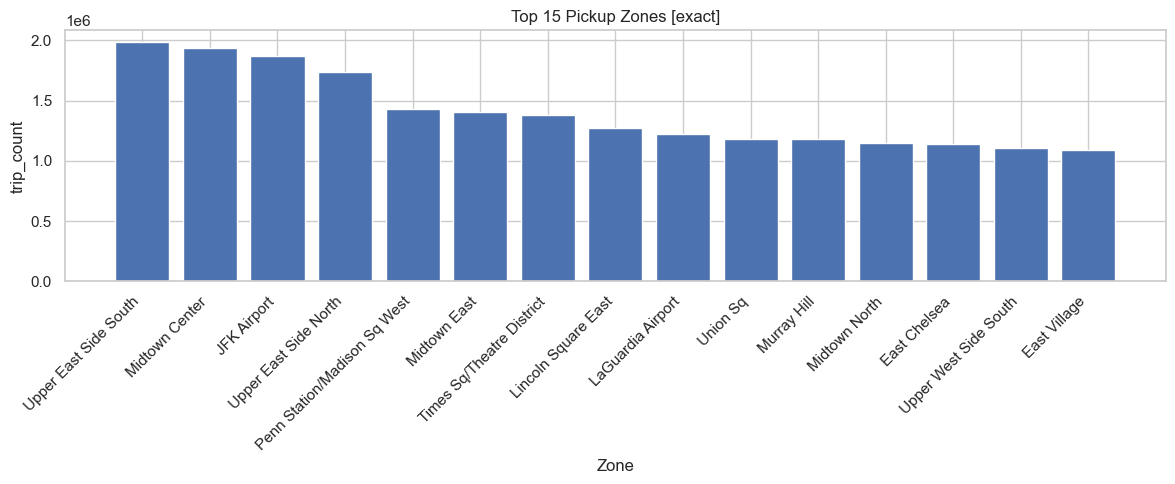

In [7]:
def top_zones_table(counts_series, label_col, n=TOP_N):
    top = counts_series.sort_values(ascending=False).head(n)
    df = top.reset_index()
    df.columns = ['LocationID', 'trip_count']
    df = df.join(zone_display, on='LocationID')
    return df[['LocationID', 'Zone', 'Borough', 'trip_count']]

pu_hotspots = top_zones_table(pu_zone_counts, 'PU')
do_hotspots = top_zones_table(do_zone_counts, 'DO')

fig = plot_bar(pu_hotspots, 'Zone', 'trip_count', title=f'Top {TOP_N} Pickup Zones [exact]', top_n=TOP_N)
save_fig(fig, f'{OUT_DIR}/05_01_pickup_hotspots.png')
fig

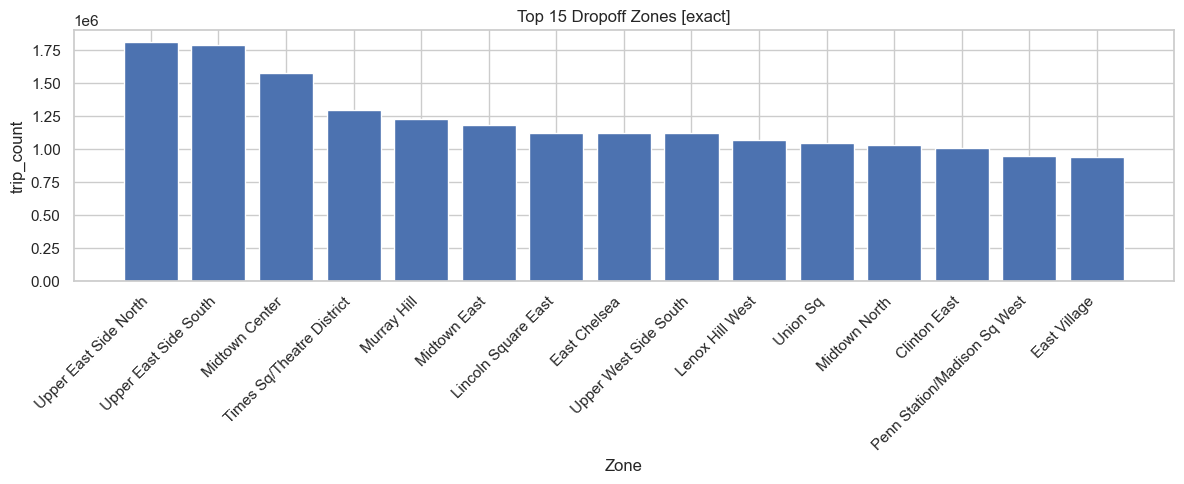

In [8]:
fig = plot_bar(do_hotspots, 'Zone', 'trip_count', title=f'Top {TOP_N} Dropoff Zones [exact]', top_n=TOP_N)
save_fig(fig, f'{OUT_DIR}/05_02_dropoff_hotspots.png')
fig

In [9]:
imbalance = pd.DataFrame({'pickups': pu_zone_counts, 'dropoffs': do_zone_counts})
imbalance = imbalance[(imbalance['pickups'] + imbalance['dropoffs']) > 1000]  # ignore near-zero-volume zones
imbalance['net_pickup_minus_dropoff'] = imbalance['pickups'] - imbalance['dropoffs']
imbalance['imbalance_ratio'] = (imbalance['pickups'] / imbalance['dropoffs'].replace(0, np.nan)).round(2)
imbalance = imbalance.join(zone_display)

print("Zones with strongest net PICKUP bias (pickup source, not destination):")
imbalance.sort_values('net_pickup_minus_dropoff', ascending=False).head(5)[['Zone', 'Borough', 'pickups', 'dropoffs', 'net_pickup_minus_dropoff']]

Zones with strongest net PICKUP bias (pickup source, not destination):


,Zone,Borough,pickups,dropoffs,net_pickup_minus_dropoff
132,JFK Airport,Queens,1874527.0,385975.0,1488552.0
138,LaGuardia Airport,Queens,1219772.0,439117.0,780655.0
186,Penn Station/Madison Sq West,Manhattan,1433263.0,950809.0,482454.0
161,Midtown Center,Manhattan,1934369.0,1580495.0,353874.0
162,Midtown East,Manhattan,1402953.0,1181793.0,221160.0


In [10]:
print("Zones with strongest net DROPOFF bias (destination, not source):")
imbalance.sort_values('net_pickup_minus_dropoff').head(5)[['Zone', 'Borough', 'pickups', 'dropoffs', 'net_pickup_minus_dropoff']]

Zones with strongest net DROPOFF bias (destination, not source):


,Zone,Borough,pickups,dropoffs,net_pickup_minus_dropoff
75,East Harlem South,Manhattan,310743.0,499956.0,-189213.0
265,Outside of NYC,NaN,9050.0,188739.0,-179689.0
50,Clinton West,Manhattan,286569.0,452141.0,-165572.0
233,UN/Turtle Bay South,Manhattan,468413.0,623145.0,-154732.0
74,East Harlem North,Manhattan,159525.0,314001.0,-154476.0


Results: JFK Airport has the strongest net-pickup bias (1,874,527 pickups against
385,975 dropoffs, +1,488,552), followed by LaGuardia Airport (+780,655) — consistent
with travelers taking a taxi away from the airport more often than a drop-off pattern
of similar scale. East Harlem South shows the strongest net-dropoff bias (310,743
pickups against 499,956 dropoffs, -189,213), alongside several other Manhattan
residential zones. Midtown Center and Penn Station/Madison Sq West are large in both
directions with a moderate pickup skew, consistent with mixed commuter and
transit-hub activity.

## 5. Borough Distribution
Pickup and dropoff share by borough.

In [11]:
borough_compare = pd.DataFrame({
    'pickup_count': borough_counts_pu, 'pickup_pct': (100*borough_counts_pu/borough_counts_pu.sum()).round(2),
    'dropoff_count': borough_counts_do, 'dropoff_pct': (100*borough_counts_do/borough_counts_do.sum()).round(2),
}).sort_values('pickup_count', ascending=False)
fig = plot_bar(borough_compare.reset_index().rename(columns={'index': 'Borough'}),
               'Borough', 'pickup_count', title='Pickups by Borough [exact]')
save_fig(fig, f'{OUT_DIR}/05_03_pickups_by_borough.png')
fig
borough_compare

,pickup_count,pickup_pct,dropoff_count,dropoff_pct
Manhattan,37862995.0,86.22,38166469.0,87.27
Queens,4159505.0,9.47,2432572.0,5.56
Brooklyn,1471915.0,3.35,2453567.0,5.61
Bronx,339624.0,0.77,493986.0,1.13
Unknown,73337.0,0.17,88924.0,0.20
Staten Island,3672.0,0.01,11559.0,0.03
EWR,1328.0,0.00,85610.0,0.20


Results: Manhattan accounts for 86.22% of pickups and 87.27% of dropoffs. Queens is
the secondary pickup source (9.47%, largely airport-driven) but a smaller dropoff share
(5.56%); Brooklyn shows the reverse pattern (3.35% of pickups, 5.61% of dropoffs),
consistent with more inbound than outbound taxi trips for that borough.

## 6. Demand & Revenue Concentration — Gini & HHI
Computed over active zones only. HHI is reported in both decimal and points scale; the
market-concentration bands used for interpretation are a descriptive reference, not a
literal competition-analysis claim.

In [12]:
def gini(shares):
    s = np.sort(shares)
    n = len(s)
    cum = np.cumsum(s)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

trip_shares = (pu_zone_counts[pu_zone_counts > 0] / pu_zone_counts.sum()).values
revenue_by_zone = zone_econ['total_sum']
revenue_shares = (revenue_by_zone[revenue_by_zone > 0] / revenue_by_zone.sum()).values

trip_gini, trip_hhi = gini(trip_shares), np.sum(trip_shares ** 2)
rev_gini, rev_hhi = gini(revenue_shares), np.sum(revenue_shares ** 2)

concentration_table = pd.DataFrame({
    'trip_volume': [round(trip_gini, 3), round(trip_hhi, 4), round(trip_hhi * 10000, 0)],
    'revenue': [round(rev_gini, 3), round(rev_hhi, 4), round(rev_hhi * 10000, 0)],
}, index=['gini', 'hhi_decimal', 'hhi_points'])
concentration_table

,trip_volume,revenue
gini,0.8230,0.8300
hhi_decimal,0.0226,0.0335
hhi_points,226.0000,335.0000


In [13]:
top_n_trip_share = 100 * pu_zone_counts.sort_values(ascending=False).head(TOP_N).sum() / pu_zone_counts.sum()
top_n_revenue_share = 100 * revenue_by_zone.sort_values(ascending=False).head(TOP_N).sum() / revenue_by_zone.sum()
print(f"[exact] top-{TOP_N} zones: {top_n_trip_share:.1f}% of trips, {top_n_revenue_share:.1f}% of revenue")
print(f"[exact] active zones (>=1 trip): {(pu_zone_counts>0).sum()} of {len(ALL_LOCATION_IDS)} total lookup zones")

[exact] top-15 zones: 48.0% of trips, 53.6% of revenue
[exact] active zones (>=1 trip): 262 of 265 total lookup zones


Results: trip-volume Gini is 0.823 (HHI 226 points); revenue Gini is 0.830 (HHI 335
points) — revenue is more concentrated than trip volume. The top 15 zones account for
48.0% of trips but 53.6% of revenue, confirming the same pattern: a modest number of
zones generate a disproportionate share of revenue relative to their trip share. 262 of
265 lookup zones recorded at least one trip.

## 7. Origin-Destination Flows
Self-pairs excluded before aggregation. Revenue and distance/duration rankings are
restricted to pairs with at least 50 trips, so a handful of one-off trips cannot
produce an unstable mean.

In [14]:
def od_table_from_matrix(count_m, value_sums, min_volume=None):
    stacked = count_m.stack()
    stacked = stacked[stacked > 0]
    stacked.index.names = ['PULocationID', 'DOLocationID']
    df = stacked.reset_index(name='trip_count')
    for name, m in value_sums.items():
        s = m.stack()
        s.index.names = ['PULocationID', 'DOLocationID']
        df[name] = df.set_index(['PULocationID', 'DOLocationID']).index.map(s)
    for name in value_sums:
        df[f'mean_{name.replace("_sum","")}'] = (df[name] / df['trip_count']).round(2)
    if min_volume:
        df = df[df['trip_count'] >= min_volume]
    df = df.join(zone_display, on='PULocationID').rename(columns={'Zone': 'PU_Zone', 'Borough': 'PU_Borough'})
    df = df.join(zone_display, on='DOLocationID').rename(columns={'Zone': 'DO_Zone', 'Borough': 'DO_Borough'})
    return df

od_full = od_table_from_matrix(od_count, {'fare_sum': od_fare_sum, 'distance_sum': od_distance_sum, 'duration_sum': od_duration_sum})

top_od_by_volume = od_full.sort_values('trip_count', ascending=False).head(TOP_N)
top_od_by_volume['od_pair'] = top_od_by_volume['PU_Zone'] + ' -> ' + top_od_by_volume['DO_Zone']
fig = plot_bar(top_od_by_volume, 'od_pair', 'trip_count', title=f'Top {TOP_N} OD Flows by Volume (self-pairs excluded) [exact]')
save_fig(fig, f'{OUT_DIR}/05_04_top_od_by_volume.png')
fig
top_od_by_volume[['PU_Zone', 'DO_Zone', 'trip_count', 'mean_fare', 'mean_distance']]

,PU_Zone,DO_Zone,trip_count,mean_fare,mean_distance
48577,Upper East Side South,Upper East Side North,287927.0,8.86,1.93
48324,Upper East Side North,Upper East Side South,245236.0,9.34,1.02
32600,Midtown Center,Upper East Side South,135895.0,10.63,1.05
48504,Upper East Side South,Midtown Center,125848.0,10.85,2.08
32599,Midtown Center,Upper East Side North,109820.0,14.57,1.90
48505,Upper East Side South,Midtown East,101029.0,9.83,1.21
28515,Lincoln Square East,Upper West Side South,99700.0,8.12,0.98
49071,Upper West Side South,Upper West Side North,96506.0,7.29,0.84
48979,Upper West Side South,Lincoln Square East,95809.0,7.92,1.81
48252,Upper East Side North,Midtown Center,95161.0,15.03,3.66


In [15]:
od_filtered = od_full[od_full['trip_count'] >= MIN_OD_VOLUME]
print(f"[exact] {len(od_filtered):,} of {len(od_full):,} OD pairs meet MIN_OD_VOLUME={MIN_OD_VOLUME} for revenue/distance ranking")

top_od_by_revenue = od_filtered.sort_values('fare_sum', ascending=False).head(TOP_N)
top_od_by_revenue[['PU_Zone', 'DO_Zone', 'trip_count', 'fare_sum', 'mean_fare', 'mean_distance', 'mean_duration']].round(0)

[exact] 20,764 of 54,637 OD pairs meet MIN_OD_VOLUME=50 for revenue/distance ranking


,PU_Zone,DO_Zone,trip_count,fare_sum,mean_fare,mean_distance,mean_duration
26155,JFK Airport,Outside of NYC,88565.0,9529004.0,108.0,21.0,45.0
26120,JFK Airport,Times Sq/Theatre District,82177.0,5838015.0,71.0,18.0,62.0
27529,LaGuardia Airport,Times Sq/Theatre District,74855.0,3815800.0,51.0,10.0,41.0
26055,JFK Airport,Midtown South,45153.0,3516855.0,78.0,17.0,52.0
25944,JFK Airport,Clinton East,41480.0,2946439.0,71.0,18.0,61.0
48577,Upper East Side South,Upper East Side North,287927.0,2551115.0,9.0,2.0,8.0
26054,JFK Airport,Midtown North,35967.0,2550343.0,71.0,18.0,61.0
26052,JFK Airport,Midtown Center,34761.0,2459156.0,71.0,17.0,57.0
46741,Times Sq/Theatre District,LaGuardia Airport,47047.0,2451701.0,52.0,15.0,36.0
27564,LaGuardia Airport,Outside of NYC,21284.0,2413564.0,113.0,22.0,46.0


Results: the highest-volume OD pair is Upper East Side South to Upper East Side
North (287,927 trips, mean fare $8.86, mean distance 1.93 miles) — a short intra-zone
crosstown pattern. 20,764 of 54,637 observed OD pairs meet the 50-trip threshold for
revenue ranking. The highest-revenue qualifying pair is JFK Airport to Outside of NYC
($9.53 million, mean fare $108, mean distance 21 miles, mean duration 45 minutes) —
airport-to-long-distance routes dominate revenue despite far lower trip counts than the
short intra-Manhattan pairs that dominate by volume.

## 8. Borough-to-Borough Flow Matrix

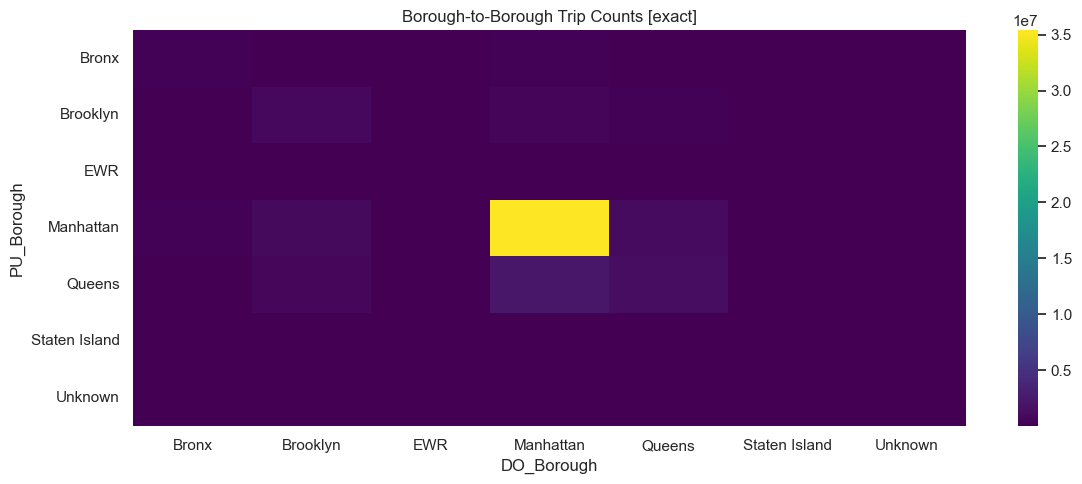

In [16]:
fig = plot_heatmap(borough_od_matrix, title='Borough-to-Borough Trip Counts [exact]', fmt=',.0f')
save_fig(fig, f'{OUT_DIR}/05_05_borough_od_heatmap.png')
fig

Results: the matrix is dominated by Manhattan-to-Manhattan trips, consistent with
Section 5's borough shares. Queens and Brooklyn each show a visible but smaller
cross-borough flow into Manhattan.

## 9. Zone-Level Economics
Fare, distance, toll incidence, and observed credit-card tip rate by pickup zone,
restricted to zones with at least 5,000 trips for stable averages.

In [17]:
zone_econ_stats = zone_econ[zone_econ['trip_count'] >= MIN_ZONE_TEST_SIZE].copy()
zone_econ_stats['avg_fare'] = zone_econ_stats['fare_sum'] / zone_econ_stats['trip_count']
zone_econ_stats['avg_distance'] = zone_econ_stats['distance_sum'] / zone_econ_stats['trip_count']
zone_econ_stats['avg_duration'] = zone_econ_stats['duration_sum'] / zone_econ_stats['trip_count']
zone_econ_stats['avg_total'] = zone_econ_stats['total_sum'] / zone_econ_stats['trip_count']
zone_econ_stats['toll_incidence_pct'] = 100 * zone_econ_stats['toll_trip_count'] / zone_econ_stats['trip_count']
zone_econ_stats['card_tip_rate_pct'] = 100 * zone_econ_stats['card_tipped_count'] / zone_econ_stats['card_trip_count'].replace(0, np.nan)
zone_econ_stats = zone_econ_stats.join(zone_display)

print("Highest average-fare zones (min volume filter applied):")
zone_econ_stats.sort_values('avg_fare', ascending=False).head(10)[['Zone', 'Borough', 'trip_count', 'avg_fare', 'avg_distance', 'toll_incidence_pct']].round(2)

Highest average-fare zones (min volume filter applied):


,Zone,Borough,trip_count,avg_fare,avg_distance,toll_incidence_pct
265,Outside of NYC,NaN,9050.0,77.62,11.55,23.16
132,JFK Airport,Queens,1874527.0,63.57,15.50,45.17
219,Springfield Gardens South,Queens,10978.0,51.89,31.87,24.03
93,Flushing Meadows-Corona Park,Queens,23933.0,49.56,9.24,35.47
10,Baisley Park,Queens,21152.0,48.01,20.76,28.62
138,LaGuardia Airport,Queens,1219772.0,45.55,9.66,64.01
86,Far Rockaway,Queens,8835.0,45.06,17.33,19.95
117,Hammels/Arverne,Queens,8396.0,44.90,29.31,29.28
70,East Elmhurst,Queens,125953.0,43.77,9.26,61.04
216,South Ozone Park,Queens,36198.0,42.84,13.06,12.72


In [18]:
print("Highest toll-incidence zones -- candidates for airport/bridge-crossing routes:")
zone_econ_stats.sort_values('toll_incidence_pct', ascending=False).head(10)[['Zone', 'Borough', 'trip_count', 'toll_incidence_pct', 'avg_fare', 'card_tip_rate_pct']].round(2)

Highest toll-incidence zones -- candidates for airport/bridge-crossing routes:


,Zone,Borough,trip_count,toll_incidence_pct,avg_fare,card_tip_rate_pct
138,LaGuardia Airport,Queens,1219772.0,64.01,45.55,95.49
70,East Elmhurst,Queens,125953.0,61.04,43.77,93.90
132,JFK Airport,Queens,1874527.0,45.17,63.57,92.81
220,Spuyten Duyvil/Kingsbridge,Bronx,7311.0,35.84,29.96,7.78
93,Flushing Meadows-Corona Park,Queens,23933.0,35.47,49.56,90.02
223,Steinway,Queens,25760.0,30.74,32.79,71.78
117,Hammels/Arverne,Queens,8396.0,29.28,44.90,0.43
10,Baisley Park,Queens,21152.0,28.62,48.01,60.39
195,Red Hook,Brooklyn,16207.0,26.99,39.28,56.47
174,Norwood,Bronx,7281.0,26.42,30.87,1.53


Results: Outside of NYC has the highest average fare ($77.62, mean distance 11.55
miles), followed by JFK Airport ($63.57). LaGuardia Airport has the highest toll
incidence (64.01%), followed by East Elmhurst (61.04%) and JFK Airport (45.17%) — all
three among the highest average-fare zones as well, and all plausible bridge/tunnel or
airport-access routes. Card tip rate varies widely by zone, from under 1% (Hammels/
Arverne) to over 95% (LaGuardia Airport), independent of toll incidence or fare level.

## 10. Monthly Zone Trend & Ranking Stability
Full-year top-5 pickup zones tracked by month, plus two quantitative stability
measures: retention of the full-year top-5 within each month's own top-5, and
month-to-month rank correlation among zones with at least 5,000 trips.

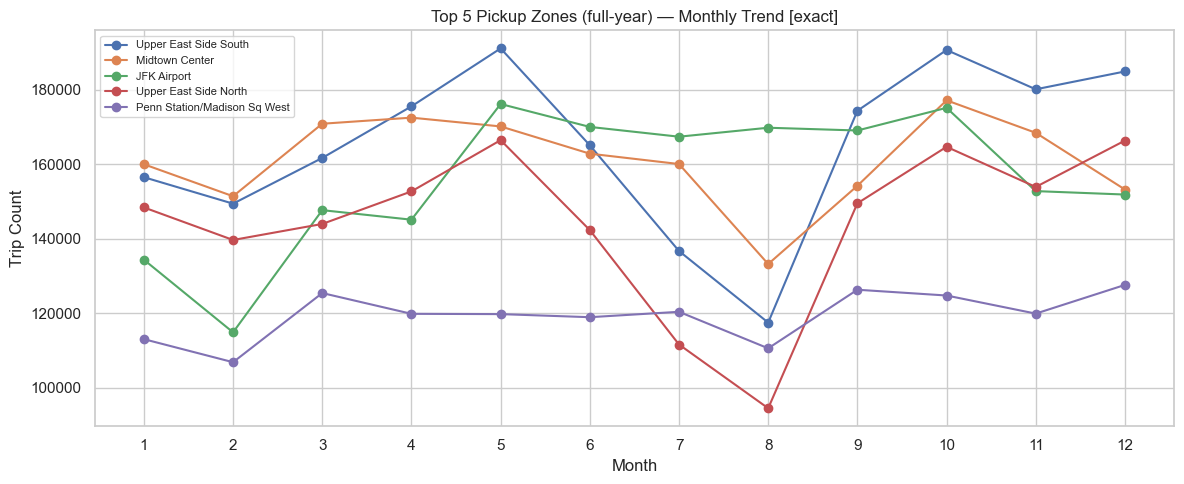

In [19]:
top5_fullyear = pu_zone_counts.sort_values(ascending=False).head(5).index.tolist()
zone_month_top5 = zone_month.loc[top5_fullyear].reindex(columns=list(MONTHS), fill_value=0)
zone_month_top5_named = zone_month_top5.join(zone_display)[['Zone'] + list(MONTHS)].set_index('Zone')

monthly_totals = zone_month.sum(axis=0)
zone_month_share_top5 = (zone_month_top5.div(monthly_totals, axis=1) * 100).round(2)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
for loc_id in top5_fullyear:
    label = zone_display.loc[loc_id, 'Zone']
    ax.plot(MONTHS, zone_month.loc[loc_id, list(MONTHS)], marker='o', label=label)
ax.set_xlabel('Month')
ax.set_ylabel('Trip Count')
ax.set_title('Top 5 Pickup Zones (full-year) — Monthly Trend [exact]')
ax.set_xticks(list(MONTHS))
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
save_fig(fig, f'{OUT_DIR}/05_06_top_zones_monthly_trend.png')
fig

In [20]:
retention_per_month = []
for m in MONTHS:
    month_top5 = zone_month[m].sort_values(ascending=False).head(5).index.tolist()
    retention_per_month.append(len(set(top5_fullyear) & set(month_top5)) / 5)
top5_retention_rate = np.mean(retention_per_month)

active_zones = pu_zone_counts[pu_zone_counts >= MIN_ZONE_TEST_SIZE].index.tolist()
rank_matrix = zone_month.loc[active_zones].rank(ascending=False, axis=0)
consecutive_corrs = [stats.spearmanr(rank_matrix[m], rank_matrix[m+1]).correlation for m in list(MONTHS)[:-1]]
avg_rank_correlation = np.nanmean(consecutive_corrs)

print(f"[exact] full-year top-5 zone retention in monthly top-5: {top5_retention_rate:.2f} "
      f"(1.0 = same 5 zones every month, 0.0 = complete turnover)")
print(f"[exact] average month-to-month Spearman rank correlation among active zones: {avg_rank_correlation:.3f} "
      f"(1.0 = identical ranking, 0 = no relationship)")
print("Stability criterion used for the Findings section: retention >= 0.8 AND rank correlation >= 0.8 => 'stable'.")

[exact] full-year top-5 zone retention in monthly top-5: 0.87 (1.0 = same 5 zones every month, 0.0 = complete turnover)
[exact] average month-to-month Spearman rank correlation among active zones: 0.993 (1.0 = identical ranking, 0 = no relationship)
Stability criterion used for the Findings section: retention >= 0.8 AND rank correlation >= 0.8 => 'stable'.


Results: the full-year top-5 zones remain in each month's own top-5 at a rate of
0.87, and the average month-to-month Spearman rank correlation among active zones is
0.993. Both exceed the notebook's stability criterion (retention and correlation both
at least 0.8); pickup-zone rankings are stable across the year, not driven by a
seasonal reshuffling of which zones dominate.

## 11. Zone × Hour Heatmaps
Pickup-zone activity by pickup hour, and dropoff-zone activity by dropoff hour — using
each side's own clock, not a shared one — plus a share-normalized view so lower-volume
but hourly-peaky zones remain visible alongside high-volume flat ones.

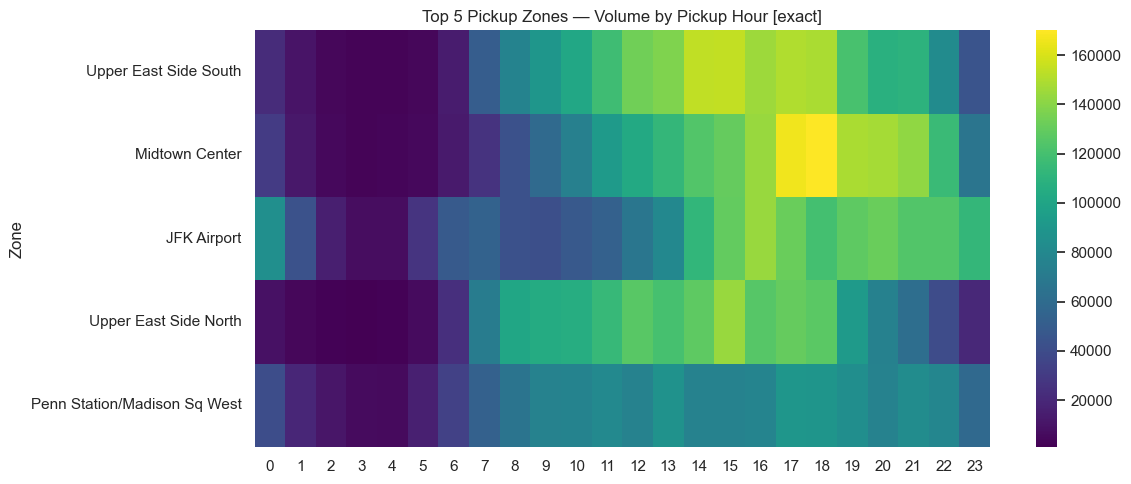

In [21]:
top5_pu_ids = pu_zone_counts.sort_values(ascending=False).head(5).index.tolist()
zone_hour_pu_top5 = zone_hour_pu.loc[top5_pu_ids].join(zone_display)['Zone']
plot_df = zone_hour_pu.loc[top5_pu_ids].copy()
plot_df.index = zone_display.loc[top5_pu_ids, 'Zone']
fig = plot_heatmap(plot_df, title='Top 5 Pickup Zones — Volume by Pickup Hour [exact]')
save_fig(fig, f'{OUT_DIR}/05_07_top_pickup_zones_by_hour.png')
fig

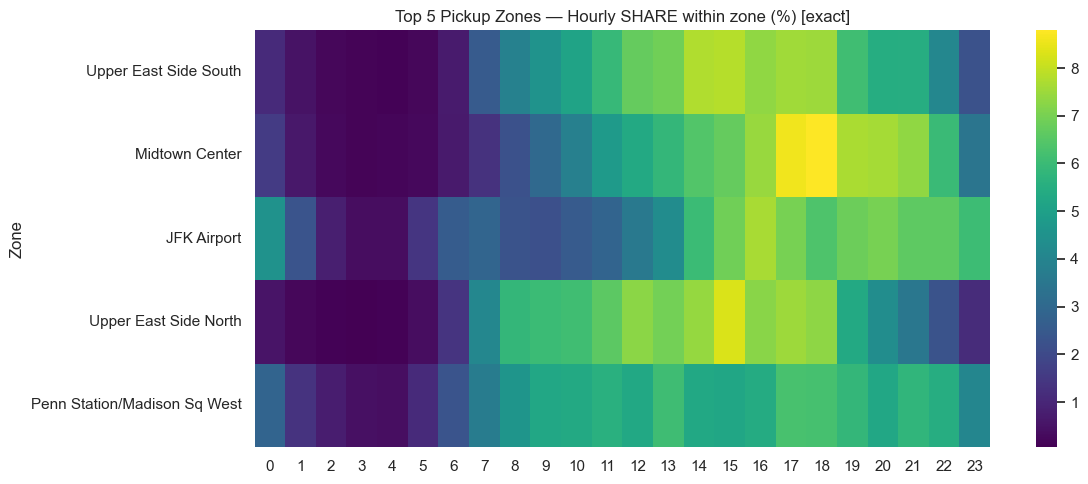

In [22]:
# normalized version: each zone's own hourly share, so low-volume-but-peaky zones aren't invisible
plot_df_norm = plot_df.div(plot_df.sum(axis=1), axis=0) * 100
fig = plot_heatmap(plot_df_norm, title='Top 5 Pickup Zones — Hourly SHARE within zone (%) [exact]')
save_fig(fig, f'{OUT_DIR}/05_08_top_pickup_zones_by_hour_normalized.png')
fig

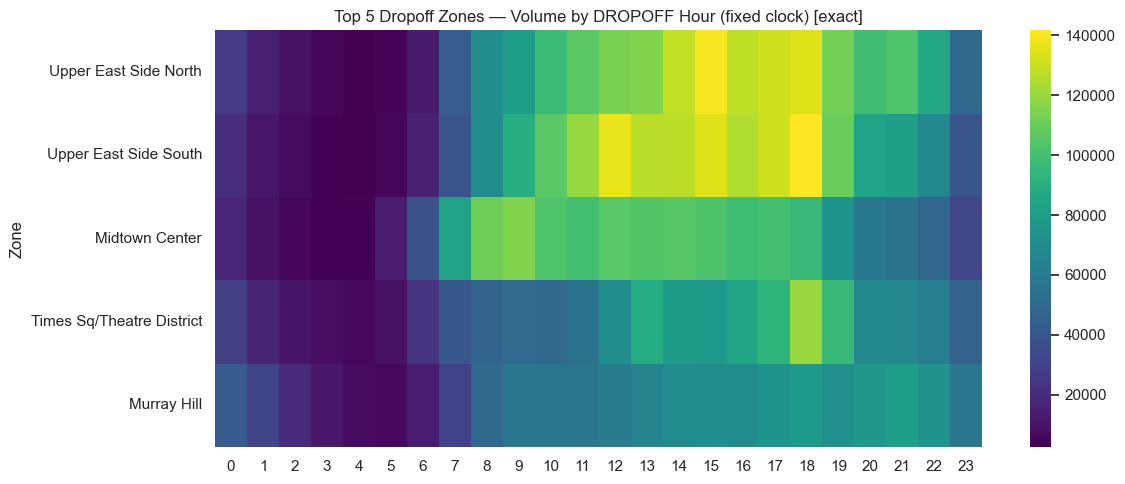

In [23]:
top5_do_ids = do_zone_counts.sort_values(ascending=False).head(5).index.tolist()
plot_df_do = zone_hour_do.loc[top5_do_ids].copy()
plot_df_do.index = zone_display.loc[top5_do_ids, 'Zone']
fig = plot_heatmap(plot_df_do, title='Top 5 Dropoff Zones — Volume by DROPOFF Hour (fixed clock) [exact]')
save_fig(fig, f'{OUT_DIR}/05_09_top_dropoff_zones_by_hour.png')
fig

Results: the top pickup and dropoff zones follow the citywide hourly pattern
established in notebook 03 — low overnight, rising through the day, peaking in the
early evening — with no zone showing a materially different hourly shape once
normalized to its own share, aside from the airport zones' comparatively flatter
profile consistent with flight schedules rather than a commute peak.

## 12. Weekday vs Weekend Zone Mix
Two tests: the top-10 pickup zones only, and a second test across all 191 zones with
at least 5,000 trips. Effect size and standardized residuals are the primary reading
given the sample size — the p-value is a secondary check, since it is near-guaranteed
significant regardless of the effect's practical size.

In [24]:
def weekday_weekend_test(matrix, label):
    contingency = matrix.copy()
    contingency.columns = ['weekday', 'weekend']
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    observed = contingency.values
    std_resid = (observed - expected) / np.sqrt(expected)
    resid_df = pd.DataFrame(std_resid, index=contingency.index, columns=['weekday_resid', 'weekend_resid'])
    print(f"[{label}] chi2={chi2:.2f}, dof={dof}, p={p_value:.2e} (secondary check -- huge n makes p near-guaranteed)")
    print(f"[{label}] Cramer's V = {cramers_v:.4f} "
          f"({'negligible' if cramers_v < 0.1 else 'small' if cramers_v < 0.3 else 'moderate/large'} effect, "
          f"conventional rule-of-thumb, not a formal citation)")
    return contingency, resid_df

top10_ids = pu_zone_counts.sort_values(ascending=False).head(10).index.tolist()
contingency_top10, resid_top10 = weekday_weekend_test(zone_weekend.loc[top10_ids], "top-10 subset ONLY")
contingency_top10.join(zone_display)

[top-10 subset ONLY] chi2=108230.33, dof=9, p=0.00e+00 (secondary check -- huge n makes p near-guaranteed)
[top-10 subset ONLY] Cramer's V = 0.0838 (negligible effect, conventional rule-of-thumb, not a formal citation)


,weekday,weekend,Zone,Borough
237,1560417,423533,Upper East Side South,Manhattan
161,1561560,372809,Midtown Center,Manhattan
132,1326422,548105,JFK Airport,Queens
236,1365452,368745,Upper East Side North,Manhattan
186,1026209,407054,Penn Station/Madison Sq West,Manhattan
162,1114716,288237,Midtown East,Manhattan
230,1014224,369869,Times Sq/Theatre District,Manhattan
142,929278,346287,Lincoln Square East,Manhattan
138,925575,294197,LaGuardia Airport,Queens
234,862510,318697,Union Sq,Manhattan


In [25]:
eligible_ids = pu_zone_counts[pu_zone_counts >= MIN_ZONE_TEST_SIZE].index.tolist()
assert len(eligible_ids) >= 2, (
    f"only {len(eligible_ids)} zones meet MIN_ZONE_TEST_SIZE={MIN_ZONE_TEST_SIZE:,} -- "
    f"lower the threshold or investigate why so few zones have sufficient volume before running this test."
)
print(f"\n[all-zone test] {len(eligible_ids)} zones with volume >= {MIN_ZONE_TEST_SIZE:,}")
contingency_all, resid_all = weekday_weekend_test(zone_weekend.loc[eligible_ids], "ALL eligible zones")

print("\nZones with the largest standardized residuals (biggest weekday/weekend deviation from expected):")
resid_all['abs_max_resid'] = resid_all[['weekday_resid', 'weekend_resid']].abs().max(axis=1)
resid_all.join(zone_display).sort_values('abs_max_resid', ascending=False).head(10)[
    ['Zone', 'Borough', 'weekday_resid', 'weekend_resid']].round(2)


[all-zone test] 191 zones with volume >= 5,000
[ALL eligible zones] chi2=1174491.08, dof=190, p=0.00e+00 (secondary check -- huge n makes p near-guaranteed)
[ALL eligible zones] Cramer's V = 0.1637 (small effect, conventional rule-of-thumb, not a formal citation)

Zones with the largest standardized residuals (biggest weekday/weekend deviation from expected):


,Zone,Borough,weekday_resid,weekend_resid
79,East Village,Manhattan,-222.26,348.56
148,Lower East Side,Manhattan,-204.90,321.34
161,Midtown Center,Manhattan,158.90,-249.20
249,West Village,Manhattan,-138.80,217.68
114,Greenwich Village South,Manhattan,-134.81,211.42
237,Upper East Side South,Manhattan,126.26,-198.01
236,Upper East Side North,Manhattan,119.37,-187.21
162,Midtown East,Manhattan,117.46,-184.20
144,Little Italy/NoLiTa,Manhattan,-114.11,178.95
140,Lenox Hill East,Manhattan,109.74,-172.10


Results: the top-10 subset shows a negligible effect (Cramer's V = 0.084). Across
all 191 eligible zones the effect is larger, though still small (Cramer's V = 0.164) —
the citywide answer is that zone mix does shift between weekday and weekend, more than
the top-10 subset alone would suggest. The largest deviations are nightlife-oriented
Manhattan zones skewing toward weekends (East Village, Lower East Side, West Village,
Greenwich Village South) against business-oriented Midtown and Upper East Side zones
skewing toward weekdays.

## 12b. Real-Map Visualizations
Pickup volume and revenue by zone as choropleths, an interactive pickup-intensity
heatmap, and the top origin-destination flows drawn as lines — all built from the
Section 2 accumulators, with no new aggregation. Zone centroids (used for the heatmap
and flow lines) are computed in the shapefile's native projected coordinate system for
geometric accuracy, then reprojected for display; a centroid is a positional
approximation and can sit away from where trips actually cluster within a large or
irregularly shaped zone.

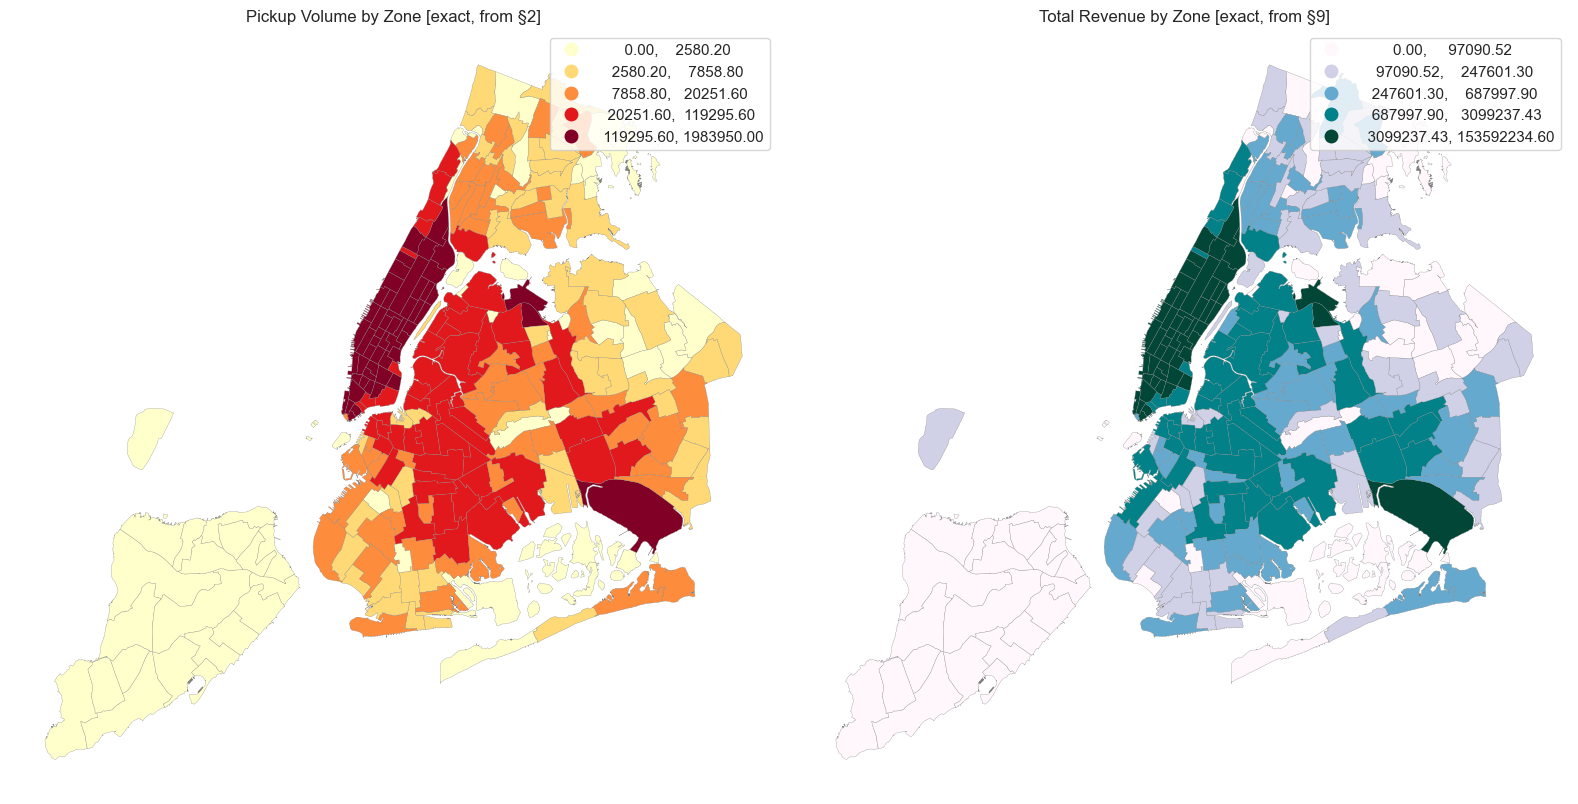

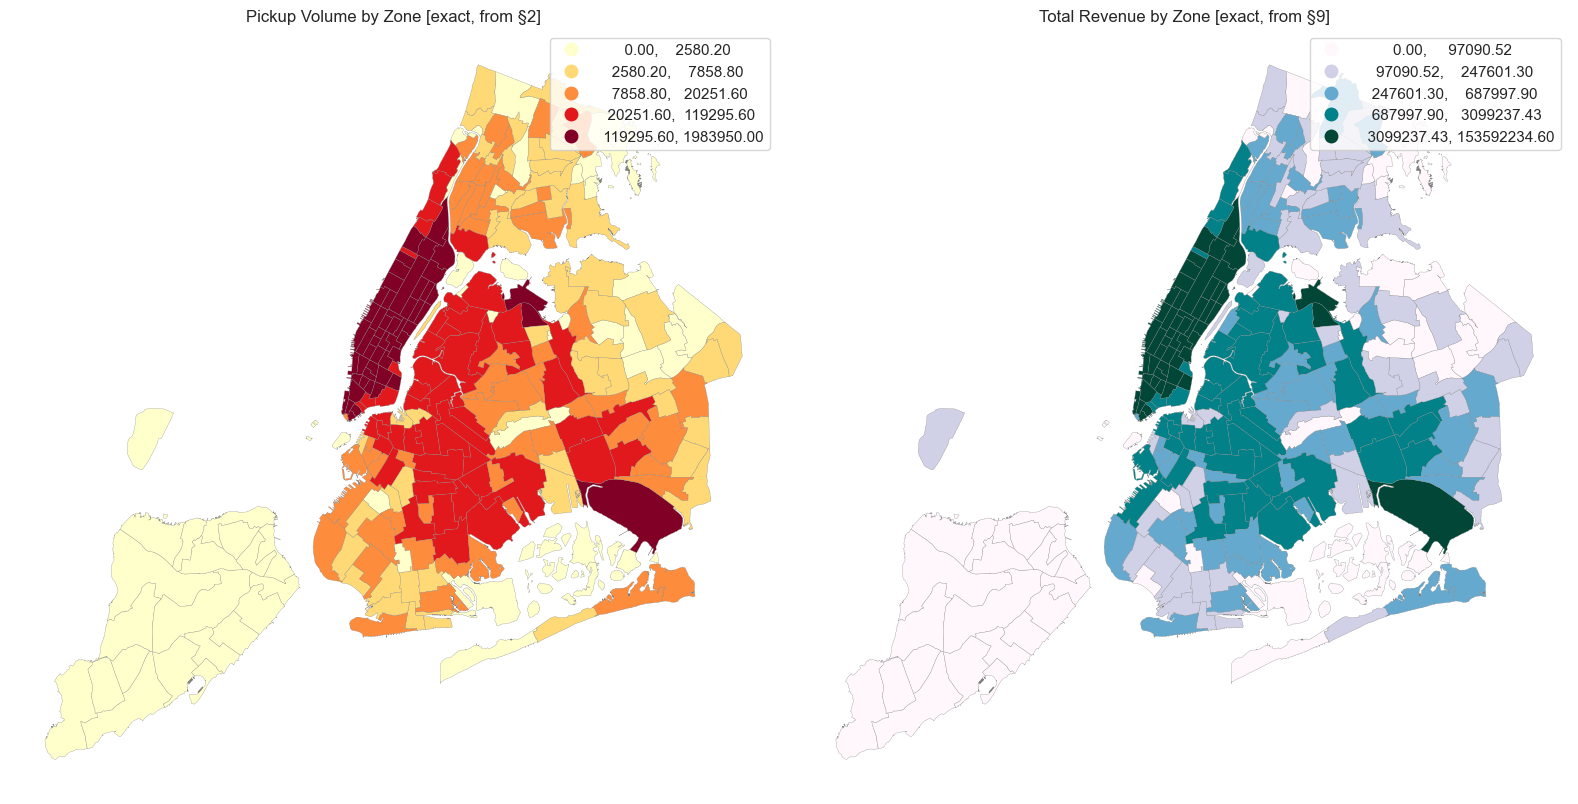

In [26]:
zones_shapes = load_zone_shapes()
gdf = zones_shapes.set_index('LocationID')

gdf_volume = gdf.join(pu_zone_counts.rename('trip_count'))
gdf_revenue = gdf.join(zone_econ['total_sum'].rename('revenue'))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
gdf_volume.plot(column='trip_count', cmap='YlOrRd', legend=True, scheme='quantiles',
                 ax=axes[0], edgecolor='grey', linewidth=0.2)
axes[0].set_title('Pickup Volume by Zone [exact, from §2]')
axes[0].axis('off')

gdf_revenue.plot(column='revenue', cmap='PuBuGn', legend=True, scheme='quantiles',
                  ax=axes[1], edgecolor='grey', linewidth=0.2)
axes[1].set_title('Total Revenue by Zone [exact, from §9]')
axes[1].axis('off')

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/05_addon_choropleth_volume_vs_revenue.png', dpi=150, bbox_inches='tight')
fig

Results: comparing the two panels zone by zone shows the pattern Section 6
quantified numerically — a zone that is mid-tier by trip volume but top-tier by revenue
is exactly the "modest trip share, outsized revenue share" effect the Gini and HHI
comparison identified, now visible spatially. Airport and outer-borough zones are the
clearest examples.

### Interactive Heatmap
Pickup intensity across all active zones, rendered as a genuine interactive map.

In [27]:
# Centroids are computed in the shapefile's native projected CRS for accuracy,
# then reprojected to WGS84 for Folium.

projected = (
    zones_shapes
    .set_index('LocationID')
    .to_crs(epsg=2263)
)

centroids_wgs84 = projected.geometry.centroid.to_crs(epsg=4326)

# Keep only LocationIDs that exist in both the trip-count data
# and the geographic shapefile.
common_location_ids = (
    pu_zone_counts.index
    .intersection(centroids_wgs84.index)
)

heat_points = [
    [
        centroids_wgs84.loc[loc_id].y,
        centroids_wgs84.loc[loc_id].x,
        int(pu_zone_counts.loc[loc_id])
    ]
    for loc_id in common_location_ids
    if pu_zone_counts.loc[loc_id] > 0
]

interactive_map = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=11,
    tiles='cartodbpositron'
)

heat_layer = folium.FeatureGroup(
    name='Pickup intensity (heatmap)'
)

HeatMap(
    heat_points,
    radius=18,
    blur=15,
    max_zoom=13
).add_to(heat_layer)

heat_layer.add_to(interactive_map)

print(
    f"[exact] {len(heat_points)} zone centroids added to heatmap layer"
)

interactive_map

[exact] 260 zone centroids added to heatmap layer


Results: 260 zone centroids plotted, weighted by full-year pickup count. The map
reproduces the Manhattan-dominant concentration established in Section 5, with the two
airport zones visible as secondary high-intensity points outside the Manhattan
core.

### Top-OD-Pair Flow Lines
The highest-volume origin-destination pairs from Section 7, drawn as lines between
zone centroids, with line weight scaled to trip volume.

In [29]:
valid_location_ids = centroids_wgs84.index

od_stacked = od_count.stack()
od_stacked = od_stacked[od_stacked > 0]

od_stacked = od_stacked[
    od_stacked.index.get_level_values(0).isin(valid_location_ids)
    & od_stacked.index.get_level_values(1).isin(valid_location_ids)
]

od_stacked = (
    od_stacked
    .sort_values(ascending=False)
    .head(TOP_N)
)

flow_layer = folium.FeatureGroup(
    name=f'Top {TOP_N} OD flows'
)

max_count = od_stacked.max()

for (pu_id, do_id), count in od_stacked.items():

    pu_pt = centroids_wgs84.loc[pu_id]
    do_pt = centroids_wgs84.loc[do_id]

    mean_fare = od_fare_sum.loc[pu_id, do_id] / count

    pu_name = zone_display.loc[pu_id, 'Zone']
    do_name = zone_display.loc[do_id, 'Zone']

    weight = 1 + 8 * (count / max_count)

    folium.PolyLine(
        [[pu_pt.y, pu_pt.x], [do_pt.y, do_pt.x]],
        weight=weight,
        opacity=0.6,
        color='crimson',
        popup=(
            f'{pu_name} -> {do_name}: '
            f'{int(count):,} trips, '
            f'mean fare ${mean_fare:.2f}'
        ),
    ).add_to(flow_layer)

flow_layer.add_to(interactive_map)

folium.LayerControl(collapsed=False).add_to(interactive_map)

interactive_map.save(
    f'{OUT_DIR}/05_addon_interactive_heatmap_and_od_flows.html'
)

print(
    f"[exact] {len(od_stacked)} OD flow lines added "
    f"(min {int(od_stacked.min()):,}, "
    f"max {int(od_stacked.max()):,} trips per pair)"
)
interactive_map

[exact] 15 OD flow lines added (min 85,149, max 287,927 trips per pair)


Results: 15 flow lines drawn, ranging from 85,149 to 287,927 trips per pair. The
heaviest lines connect adjacent Upper East Side and Upper West Side sub-zones,
consistent with Section 7's finding that the highest-volume pairs are short
intra-Manhattan hops rather than the longer, higher-revenue airport routes.

## 13. Findings, Hypotheses, Next Steps

Top findings:
- Demand is highly concentrated geographically: Midtown Center is the largest single
  pickup zone (1,934,369 trips); JFK Airport has the strongest net pickup-over-dropoff
  imbalance (+1,488,552), consistent with airport-departure demand (Section 4).
- Manhattan accounts for 86.22% of pickups and 87.27% of dropoffs; Queens is the
  secondary pickup source at 9.47%, driven largely by the two airports (Section 5).
- Revenue is more concentrated than trip volume (Gini 0.830 vs 0.823; HHI 335 vs 226
  points) — the top 15 zones generate 53.6% of revenue against 48.0% of trips
  (Section 6).
- OD volume is dominated by short intra-Manhattan hops (top pair: Upper East Side
  South to North, 287,927 trips), while OD revenue is dominated by airport routes (top
  qualifying pair: JFK Airport to Outside of NYC, $9.53 million) (Section 7).
- Airport and bridge/tunnel-access zones combine high average fare with high toll
  incidence: LaGuardia Airport (64.01% toll incidence, 45.55 dolalr average fare) and JFK
  Airport (45.17%, 63.57 dollar) are the clearest examples (Section 9).
- Pickup-zone rankings are stable across the year (0.87 top-5 retention, 0.993 average
  monthly rank correlation), well above the notebook's stability criterion (Section 10).
- The citywide weekday/weekend zone-mix effect is small but real (Cramer's V = 0.164
  across 191 zones, versus 0.084 for the top-10 subset alone); it is driven by
  nightlife-oriented zones skewing weekend and business-oriented zones skewing weekday
  (Section 12).

Quality caveats:
- Pickup and dropoff zone matching are both 100.000%; every share in this notebook
  uses the full 43,921,426-trip denominator unless a table explicitly restricts to a
  subset (Section 3).
- OD revenue and distance rankings use means, restricted to pairs with at least 50
  trips; self-pairs are excluded before aggregation (Section 7).
- Gini and HHI are computed over active zones only — the 262 of 265 lookup zones with
  at least one trip — not across all possible TLC zone codes (Section 6).
- The top-10-subset weekday/weekend result (Section 12) describes only that subset;
  the all-zone test is the citywide measure.
- Map visualizations (Section 12b) use zone centroids as a positional approximation,
  not exact trip locations.

Hypotheses worth testing further:
- The strongest pickup/dropoff imbalances are concentrated in airport and major
  transit-hub zones (Section 4); a route-level breakdown of airport trips would
  clarify whether this reflects departure timing, drop-off patterns, or both.
- High zone-level fare and toll incidence co-occur specifically at airport and
  bridge/tunnel-access zones (Section 9); notebook 04's toll-versus-non-toll comparison
  (fare $56.55 vs $17.31) is consistent with this at the population level.
- The weekday/weekend effect concentrated in nightlife zones (Section 12) suggests an
  hour-of-day interaction — combining zone, hour, and weekday/weekend jointly would
  isolate whether the effect is really about the day or about specific evening/night
  hours within it.

Next steps: proceed to `06_anomaly_analysis_and_insights.ipynb` to connect the
multivariate outliers and fare-per-mile anomalies identified in notebook 03 to the
zones, OD pairs, and toll-incidence patterns established here.